# Zonal_mpsi using UXarray

Work on [NCL's zonal_mpsi](https://www.ncl.ucar.edu/Document/Functions/Built-in/zonal_mpsi.shtml) with a UXarray dataset.

Zonal mean meridional stream function

*v*: A multi-dimensional array of meridional wind values

*lat*: A one-dimensional array of latitudes.

*p*: A one-dimensional array of pressure level values ordered top-to-bottom.

*ps*: A multi-dimensional numeric array of surface pressures.

$MPSI(lev,lat) = \frac{2 {\pi} a cos(lat)}{g} \int_{p}^{PS} \bar{v} \,dp$

In [1]:
import uxarray as ux
import xarray as xr
import numpy as np
import geocat.datafiles as gdf
import geocat.comp as gc

Need a datset with: wind speed values (lat, long, time, maybe lev), vertical pressure levels, and spatial surface pressure

## Read in Data

In [ ]:
data_path = 'netcdf_files/e2p3b09.F2000climo.ne30pg3.ctl002.cam.h0.0005-01.zonal_mpsi_subset.nc'
grid_path = 'netcdf_files/ne30pg3_scrip_170604.nc'
uxds = ux.open_dataset(gdf.get(grid_path), gdf.get(data_path)).drop('lat') #dropping lat to avoid using it instead of the UXarray grid

uxds

/var/folders/dd/_xm_pbpd3flgbvbnt7qhd70snnbpj_/T/ipykernel_91232/1559753121.py:3: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  uxds = ux.open_dataset(gdf.get(grid_path), gdf.get(data_path)).drop('lat')


<xarray.UxDataset> Size: 6MB
Dimensions:  (time: 1, n_face: 48600, lev: 32, ilev: 33)
Coordinates:
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev     (ilev) float64 264B 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
  * time     (time) object 8B 0005-02-01 00:00:00
Dimensions without coordinates: n_face
Data variables:
    PS       (time, n_face) float32 194kB ...
    V        (time, lev, n_face) float32 6MB ...
    hyam     (lev) float64 256B ...
    hybm     (lev) float64 256B ...
    hyai     (ilev) float64 264B ...
    hybi     (ilev) float64 264B ...

The data hasn't been interpolated to pressure levels (still on hybrid sigma levels)

In [3]:
# Grabbing correct data variables, confirming long names
print(#uxds.lat.attrs['long_name'],', ',
      uxds.PS.attrs['long_name'],', ',
      uxds.V.attrs['long_name'],', ',
      uxds.hyam.attrs['long_name'],', ', 
      uxds.hybm.attrs['long_name'],', ',
      uxds.hyai.attrs['long_name'],', ', 
      uxds.hybi.attrs['long_name'])

Surface pressure ,  Meridional wind ,  hybrid A coefficient at layer midpoints ,  hybrid B coefficient at layer midpoints ,  hybrid A coefficient at layer interfaces ,  hybrid B coefficient at layer interfaces


## Converting from sigma hybrid coordinates to Pressure levels

$p(k) = hya(k) * p_0 + hyb(k) * p_{surface}$

Source: [NCL `sigma2hybrid` documentation](https://www.ncl.ucar.edu/Document/Functions/Built-in/sigma2hybrid.shtml)


['geocat_comp.delta_pressure()`](https://geocat-comp.readthedocs.io/en/latest/user_api/generated/geocat.comp.meteorology.delta_pressure.html)

['geocat_comp.dpres_plev()`](https://geocat-comp.readthedocs.io/en/latest/user_api/generated/geocat.comp.meteorology.dpres_plev.html)

['geocat_comp.interp_hybrid_to_pressure()'](https://geocat-comp.readthedocs.io/en/latest/user_api/generated/geocat.comp.interpolation.interp_hybrid_to_pressure.html)

In [4]:
da_ipress = gc.interpolation.interp_hybrid_to_pressure(
    uxds.V, 
    uxds.PS, 
    uxds.hyam, 
    uxds.hybm)
da_ipress

<xarray.DataArray 'V' (time: 1, plev: 21, n_face: 48600)> Size: 4MB
dask.array<_vertical_remap, shape=(1, 21, 48600), dtype=float32, chunksize=(1, 21, 48600), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 8B 0005-02-01 00:00:00
  * plev     (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
Dimensions without coordinates: n_face
Attributes:
    mdims:         1
    units:         m/s
    long_name:     Meridional wind
    cell_methods:  time: mean

In [5]:
# Convert back to UXarray
uxda = ux.UxDataArray(da_ipress, uxgrid=uxds.uxgrid)
uxda

<xarray.UxDataArray 'V' (time: 1, plev: 21, n_face: 48600)> Size: 4MB
dask.array<_vertical_remap, shape=(1, 21, 48600), dtype=float32, chunksize=(1, 21, 48600), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 8B 0005-02-01 00:00:00
  * plev     (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
Dimensions without coordinates: n_face
Attributes:
    mdims:         1
    units:         m/s
    long_name:     Meridional wind
    cell_methods:  time: mean

## Preparing and Performing the Integral

In [6]:
# Constants
a = 6.371e6  # Earth radius (m)
g = 9.80665  # gravity (m/s^2)

lat = uxda.uxgrid.face_lat
scaling_factor = 2 * np.pi * a * np.cos(lat) / g

# zonal mean wind
v_zonal = uxda.zonal_mean()
v_zonal

## zonal mean on integration bounds
#PS_zonal = uxds.PS.zonal_mean()
#pm_zonal = uxds.pm.zonal_mean()
#pi_zonal = uxds.pi.zonal_mean()

/Users/jkent/miniconda3/envs/uxarray-where/lib/python3.13/site-packages/uxarray/grid/grid.py:1452: RuntimeWarning: Necessary functions for computing the bounds of each face are not yet compiled with Numba. This initial execution will be significantly longer.
  warn(


<xarray.UxDataArray 'V_zonal_mean' (time: 1, plev: 21, latitudes: 19)> Size: 2kB
dask.array<setitem, shape=(1, 21, 19), dtype=float32, chunksize=(1, 21, 19), chunktype=numpy.ndarray>
Coordinates:
  * latitudes  (latitudes) int64 152B -90 -80 -70 -60 -50 -40 ... 50 60 70 80 90
Dimensions without coordinates: time, plev
Attributes:
    zonal_mean:  True

In [58]:
v_zonal.isel(time=0, plev=10).plot.line()

:Curve   [latitudes]   (V_zonal_mean)

In [ ]:
dp = gc.meteorology.delta_pressure(v_zonal.plev, uxds.PS)
# doesn't need to perform this calculation spatially because it is the same at every face, but it seems to be doing so (except for the first surface pressure)
# Make this a GeoCAT function not just an application

Taking over 3 minutes to run? Seems way slower than my original method and mask combined (was over 5 in a previous run)

Outputs a numpy array despite dataarray input.

In [ ]:
v_zonal.plev #  this is indices not pressure values
# make sure this is being called

<xarray.UxDataArray 'plev' (plev: 21)> Size: 168B
array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])
Dimensions without coordinates: plev

In [ ]:
dp = gc.meteorology.delta_pressure(v_zonal.plev, uxds.PS)

In [10]:
dp

array([[[5.00000000e-01, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.01477539e+05],
        [5.00000000e-01, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.01488836e+05],
        [5.00000000e-01, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.01503188e+05],
        ...,
        [5.00000000e-01, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 9.74288359e+04],
        [5.00000000e-01, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 9.90030312e+04],
        [5.00000000e-01, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.00288570e+05]]])

In [16]:
dp.shape

(1, 48600, 21)

In [22]:
v_zonal.plev.shape

(21,)

In [28]:
uxds.PS

<xarray.UxDataArray 'PS' (time: 1, n_face: 48600)> Size: 194kB
array([[101497.04 , 101508.336, 101522.69 , ...,  97448.336,  99022.53 ,
        100308.07 ]], dtype=float32)
Coordinates:
  * time     (time) object 8B 0005-02-01 00:00:00
Dimensions without coordinates: n_face
Attributes:
    units:         Pa
    long_name:     Surface pressure
    cell_methods:  time: mean

In [33]:
# Easier if I make dp a DataArray again?
dp_da = xr.DataArray(
    dp,
    dims=["time", "n_face", "plev"],
    name="delta_pressure"
)
#dp_da

dp_ux = ux.UxDataArray(dp_da, uxgrid=uxda.uxgrid)
dp_ux

<xarray.UxDataArray 'delta_pressure' (time: 1, n_face: 48600, plev: 21)> Size: 8MB
array([[[5.00000000e-01, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.01477539e+05],
        [5.00000000e-01, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.01488836e+05],
        [5.00000000e-01, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.01503188e+05],
        ...,
        [5.00000000e-01, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 9.74288359e+04],
        [5.00000000e-01, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 9.90030312e+04],
        [5.00000000e-01, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.00288570e+05]]])
Dimensions without coordinates: time, n_face, plev

In [ ]:
mpsi = dp_da.cumsum() # double check that this is the correct orientation

In [51]:
mpsi = mpsi * scaling_factor
mpsi

<xarray.DataArray (time: 1, n_face: 48600, plev: 21)> Size: 8MB
array([[[-1.82017252e+06, -5.46051757e+06, -9.10086261e+06, ...,
         -6.73463833e+07, -7.09867284e+07, -3.69484243e+11],
        [-2.45782164e+06, -7.37346493e+06, -1.22891082e+07, ...,
         -9.09394007e+07, -9.58550440e+07, -4.98951004e+11],
        [-1.24173946e+06, -3.72521839e+06, -6.20869731e+06, ...,
         -4.59443601e+07, -4.84278390e+07, -2.52096342e+11],
        ...,
        [ 5.01533781e+10,  1.50460134e+11,  2.50766891e+11, ...,
          1.85567499e+12,  1.95598175e+12,  9.88997452e+15],
        [ 7.55364103e+09,  2.26609231e+10,  3.77682051e+10, ...,
          2.79484718e+11,  2.94592000e+11,  1.48953723e+15],
        [-3.78163363e+10, -1.13449009e+11, -1.89081681e+11, ...,
         -1.39920444e+12, -1.47483712e+12, -7.45718002e+15]]])
Dimensions without coordinates: time, n_face, plev

# Plotting

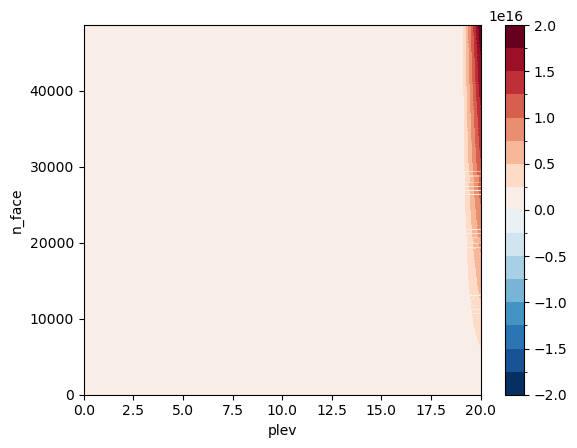

In [52]:
# Select a single n_face (e.g., the first one) for plotting
# Use plev as the vertical axis and plot against its values
mpsi.isel(time=0).plot.contourf(x='plev', levels=20, add_colorbar=True)

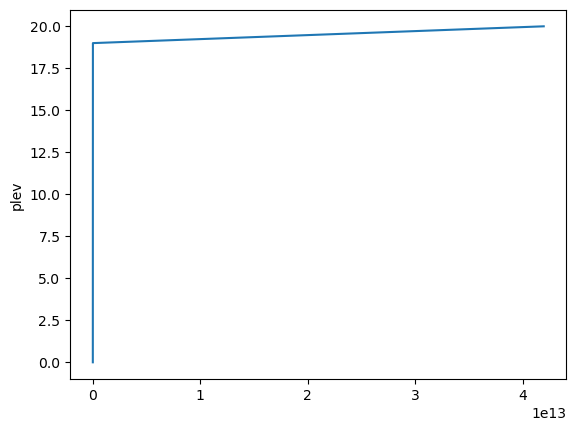

In [53]:
mpsi.isel(time=0, n_face=100).plot(y='plev')

I'm getting confused about how my mpsi has both ilev (from interface pressures) and lev (from midpoint pressures). These are linked, in that I probably want to drop one of them.

Also having latitude as a variable separate from the grid information. I'll want to touch base on this.

In [54]:
mpsi_ux = ux.UxDataArray(mpsi, uxgrid=uxda.uxgrid)
mpsi_ux

<xarray.UxDataArray (time: 1, n_face: 48600, plev: 21)> Size: 8MB
array([[[-1.82017252e+06, -5.46051757e+06, -9.10086261e+06, ...,
         -6.73463833e+07, -7.09867284e+07, -3.69484243e+11],
        [-2.45782164e+06, -7.37346493e+06, -1.22891082e+07, ...,
         -9.09394007e+07, -9.58550440e+07, -4.98951004e+11],
        [-1.24173946e+06, -3.72521839e+06, -6.20869731e+06, ...,
         -4.59443601e+07, -4.84278390e+07, -2.52096342e+11],
        ...,
        [ 5.01533781e+10,  1.50460134e+11,  2.50766891e+11, ...,
          1.85567499e+12,  1.95598175e+12,  9.88997452e+15],
        [ 7.55364103e+09,  2.26609231e+10,  3.77682051e+10, ...,
          2.79484718e+11,  2.94592000e+11,  1.48953723e+15],
        [-3.78163363e+10, -1.13449009e+11, -1.89081681e+11, ...,
         -1.39920444e+12, -1.47483712e+12, -7.45718002e+15]]])
Dimensions without coordinates: time, n_face, plev

In [ ]:
mpsi_ux.isel(time=0, plev=10).plot() #zonal mean, so longitude are not meaningful here

:Image   [x,y]   (x_y var)